In [14]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from etc.parse_ids import XMLParser

# Get the notebook's directory and go up to project root
notebook_dir = Path().resolve()
project_root = notebook_dir.parent
data_folder = project_root / "data" / "resources"
Estelle = data_folder / "Estelle"
output_dir = project_root / "results"

# Get graph prevouly fitered
graph_gml = data_folder / "generated" / "modified_graph.gml"
# Get the original graph for matching ids
human1_xml = data_folder / "Human-GEM.xml"

In [8]:
list_of_files = ("Liu", "Gonzalez","COMETS", "Pietzner","MTH","Hajjar")
combined_file = (Estelle/"liu.txt", Estelle/"gonzalez.txt", Estelle/"COMETS.txt", 
                 Estelle/"pietznzer.txt", Estelle/"MTH.txt", Estelle/"Estelle.txt")

In [9]:
# Run after correcting the two cells above.
parser = XMLParser(human1_xml)
parser.extract_data()
df_human1 = parser.to_identifier_df()

for name, path in zip(list_of_files, combined_file):
    ids = set(path.read_text().split())
    df_human1[name] = df_human1.index.isin(ids).astype(int)

df_human1.head()

,chebi,kegg,metanetx,vmhmetabolite,hmdb,lipidmaps,pubchem,Liu,Gonzalez,COMETS,Pietzner,MTH,Hajjar
HUMAN1_ID,,,,,,,,,,,,,
MAM00001c,15389,C00964,MNXM45735,carveol,NaN,NaN,NaN,0,0,0,0,0,0
MAM00001e,15389,C00964,MNXM45735,carveol,NaN,NaN,NaN,0,0,0,0,0,0
MAM00002c,36740,C09880,MNXM163755,appnn,HMDB0006525,NaN,6654,0,0,0,0,0,0
MAM00002e,36740,C09880,MNXM163755,appnn,HMDB0006525,NaN,6654,0,0,0,0,0,0
MAM00003c,78990,NaN,MNXM150165,M00003,NaN,LMFA01030283,NaN,0,0,0,0,0,0


In [11]:
import networkx as nx

graph = nx.read_gml(graph_gml)
graph_nodes = list(graph.nodes())
node_to_index = {node: i for i, node in enumerate(graph_nodes)}

experiment_indices = {}

for name in list_of_files:
    observed_ids = df_human1.index[df_human1[name] == 1]
    experiment_indices[name] = [
        node_to_index[node]
        for node in observed_ids
        if node in node_to_index
    ]
    print(f"{name}: {len(observed_ids)} Human1 IDs → "
          f"{len(experiment_indices[name])} nodes in the filtered graph")

Liu: 1002 Human1 IDs → 263 nodes in the filtered graph
Gonzalez: 902 Human1 IDs → 241 nodes in the filtered graph
COMETS: 827 Human1 IDs → 204 nodes in the filtered graph
Pietzner: 760 Human1 IDs → 190 nodes in the filtered graph
MTH: 682 Human1 IDs → 176 nodes in the filtered graph
Hajjar: 1527 Human1 IDs → 420 nodes in the filtered graph


/home/scostagonza/Documents/ETC/Effective-Topological-Coverage-ETC/venv/lib/python3.12/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/scostagonza/Documents/ETC/Effective-Topological-Coverage-ETC/venv/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead

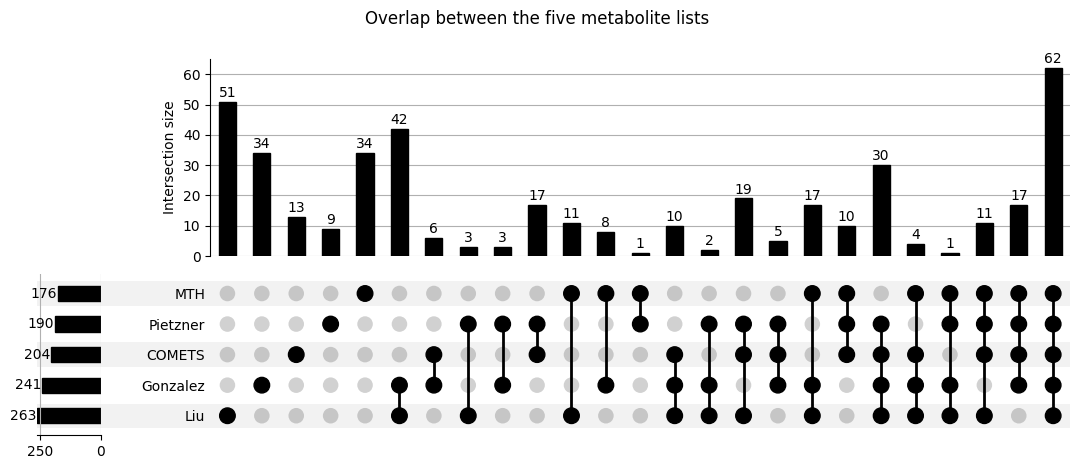

In [15]:
from upsetplot import UpSet, from_memberships
import matplotlib.pyplot as plt

individual_sets = {
    name: set(experiment_indices[name])
    for name in list_of_files[:-1]
}

all_observed = sorted(set().union(*individual_sets.values()))
memberships = [
    tuple(name for name, nodes in individual_sets.items() if index in nodes)
    for index in all_observed
]

UpSet(from_memberships(memberships), subset_size="count",
      show_counts=True).plot()
plt.suptitle("Overlap between the five metabolite lists")
plt.savefig(output_dir/"Overlap_mapped_estelle.png")
plt.show()

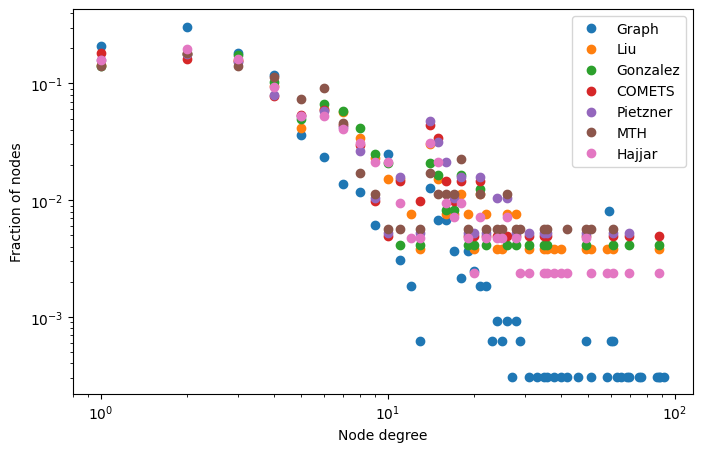

In [16]:
degrees = np.array([graph.degree(node) for node in graph_nodes])

fig, ax = plt.subplots(figsize=(8, 5))

for name, selected in {"Graph": range(len(graph_nodes)),
                       **experiment_indices}.items():
    values, counts = np.unique(degrees[list(selected)], return_counts=True)
    positive = values > 0
    ax.loglog(values[positive],
              (counts / counts.sum())[positive],
              "o", label=name)

ax.set_xlabel("Node degree")
ax.set_ylabel("Fraction of nodes")
ax.legend()
plt.show()

In [17]:
combined_name = list_of_files[-1]
observed_nodes = [
    graph_nodes[i] for i in experiment_indices[combined_name]
]

connector_nodes = set(observed_nodes)

for i, source in enumerate(observed_nodes):
    paths = nx.single_source_shortest_path(graph, source)
    for target in observed_nodes[i + 1:]:
        connector_nodes.update(paths[target])

G_observed = graph.subgraph(connector_nodes).copy()

print(f"Observed nodes: {len(observed_nodes)}")
print(f"Connector subgraph: {G_observed.number_of_nodes()} nodes, "
      f"{G_observed.number_of_edges()} edges")

Observed nodes: 420
Connector subgraph: 957 nodes, 1963 edges


In [ ]:
from etc.hamiltonian import Hamiltonian
from etc.optimization import EnergyOptimizer

H = Hamiltonian(graph)
optimizer = EnergyOptimizer(H)

mu = 0.9986, gamma = 0.0677


,k,H,T1,T2,E
Liu,263,-111.928045,-215.701389,103.773345,111.928045
Gonzalez,241,-99.114967,-191.734568,92.619601,99.114967
COMETS,204,-41.930549,-106.852077,64.921528,41.930549
Pietzner,190,-31.775388,-87.878344,56.102956,31.775388
MTH,176,-50.237097,-94.868667,44.631570,50.237097
Hajjar,420,-158.302098,-417.422133,259.120035,158.302098


In [ ]:
mu = H.mu_density_aware(graph)
gamma = (1 - mu)*7*7

h_values = {
    name: H.compute(indices, gamma=gamma, mu=mu)
    for name, indices in experiment_indices.items()
}

h_table = pd.DataFrame.from_dict(
    h_values, orient="index", columns=["H", "T1", "T2"]
)
h_table.insert(0, "k", [len(experiment_indices[name]) for name in h_table.index])
h_table["E"] = h_table["H"].abs()

print(f"mu = {mu:.4f}, gamma = {gamma:.4f}")
display(h_table)

In [19]:
distance_matrix = nx.floyd_warshall_numpy(graph)

In [ ]:
random_H = {}

for name, indices in experiment_indices.items():
    sampled_H = optimizer.sampling_h(
        n=len(graph_nodes),
        k=len(indices),
        gamma=gamma,
        mu=mu,
        n_samples=10000,
        n_workers=8,
        seed=42,
    )[0]

    random_H[name] = np.asarray(sampled_H)
    print(
        f"{name} (k={len(indices)}): "
        f"observed H={h_table.loc[name, 'H']:.3f}, "
        f"random H range={random_H[name].min():.3f}–{random_H[name].max():.3f}"
    )

Liu (k=263): observed H=-111.928, random E range=-28.683–57.754
Gonzalez (k=241): observed H=-99.115, random E range=-27.589–51.949
COMETS (k=204): observed H=-41.931, random E range=-23.581–38.917
Pietzner (k=190): observed H=-31.775, random E range=-25.839–35.048
MTH (k=176): observed H=-50.237, random E range=-18.308–33.018
Hajjar (k=420): observed H=-158.302, random E range=-33.181–125.615


In [24]:
initial_masks = {}

for name, indices in experiment_indices.items():
    farthest_nodes = optimizer.farthest_nodes_sample(
        graph=graph,
        k=len(indices),
        seed=42,
        distance_matrix=distance_matrix,
    )
    initial_masks[name] = optimizer.create_S0_mask(
        farthest_nodes, graph.nodes()
    )

In [25]:
emax_values = {}

for name, s0 in initial_masks.items():
    emax_values[name] = optimizer.max_energy_annealing(
        s0,
        gamma=gamma,
        mu=mu,
        steps=10_000,
        n_workers=8,
        Tmin=1e-60,
    )[1]

    print(f"{name}: estimated Emax = {emax_values[name]:.4f}")

Liu: estimated Emax = 242.3040
Gonzalez: estimated Emax = 250.3718
COMETS: estimated Emax = 243.6975
Pietzner: estimated Emax = 201.9515
MTH: estimated Emax = 175.2841
Hajjar: estimated Emax = 383.5704


In [26]:
coverage_table = h_table.copy()
coverage_table["Emax"] = pd.Series(emax_values)

assert (coverage_table["Emax"] >= coverage_table["E"]).all(), (
    "An estimated Emax is below the observed E; rerun the optimization."
)

coverage_table["coverage"] = (
    1 - coverage_table["E"] / coverage_table["Emax"]
)

display(coverage_table.sort_values("coverage", ascending=False))

,k,H,T1,T2,E,Emax,coverage
Pietzner,190,-31.775388,-87.878344,56.102956,31.775388,201.951459,0.842658
COMETS,204,-41.930549,-106.852077,64.921528,41.930549,243.697488,0.827940
MTH,176,-50.237097,-94.868667,44.631570,50.237097,175.284109,0.713396
Gonzalez,241,-99.114967,-191.734568,92.619601,99.114967,250.371820,0.604129
Hajjar,420,-158.302098,-417.422133,259.120035,158.302098,383.570356,0.587293
Liu,263,-111.928045,-215.701389,103.773345,111.928045,242.303988,0.538068


In [27]:
observed_by_list = {
    name: {graph_nodes[i] for i in experiment_indices[name]}
    for name in list_of_files[:-1]
}
all_observed = set().union(*observed_by_list.values())

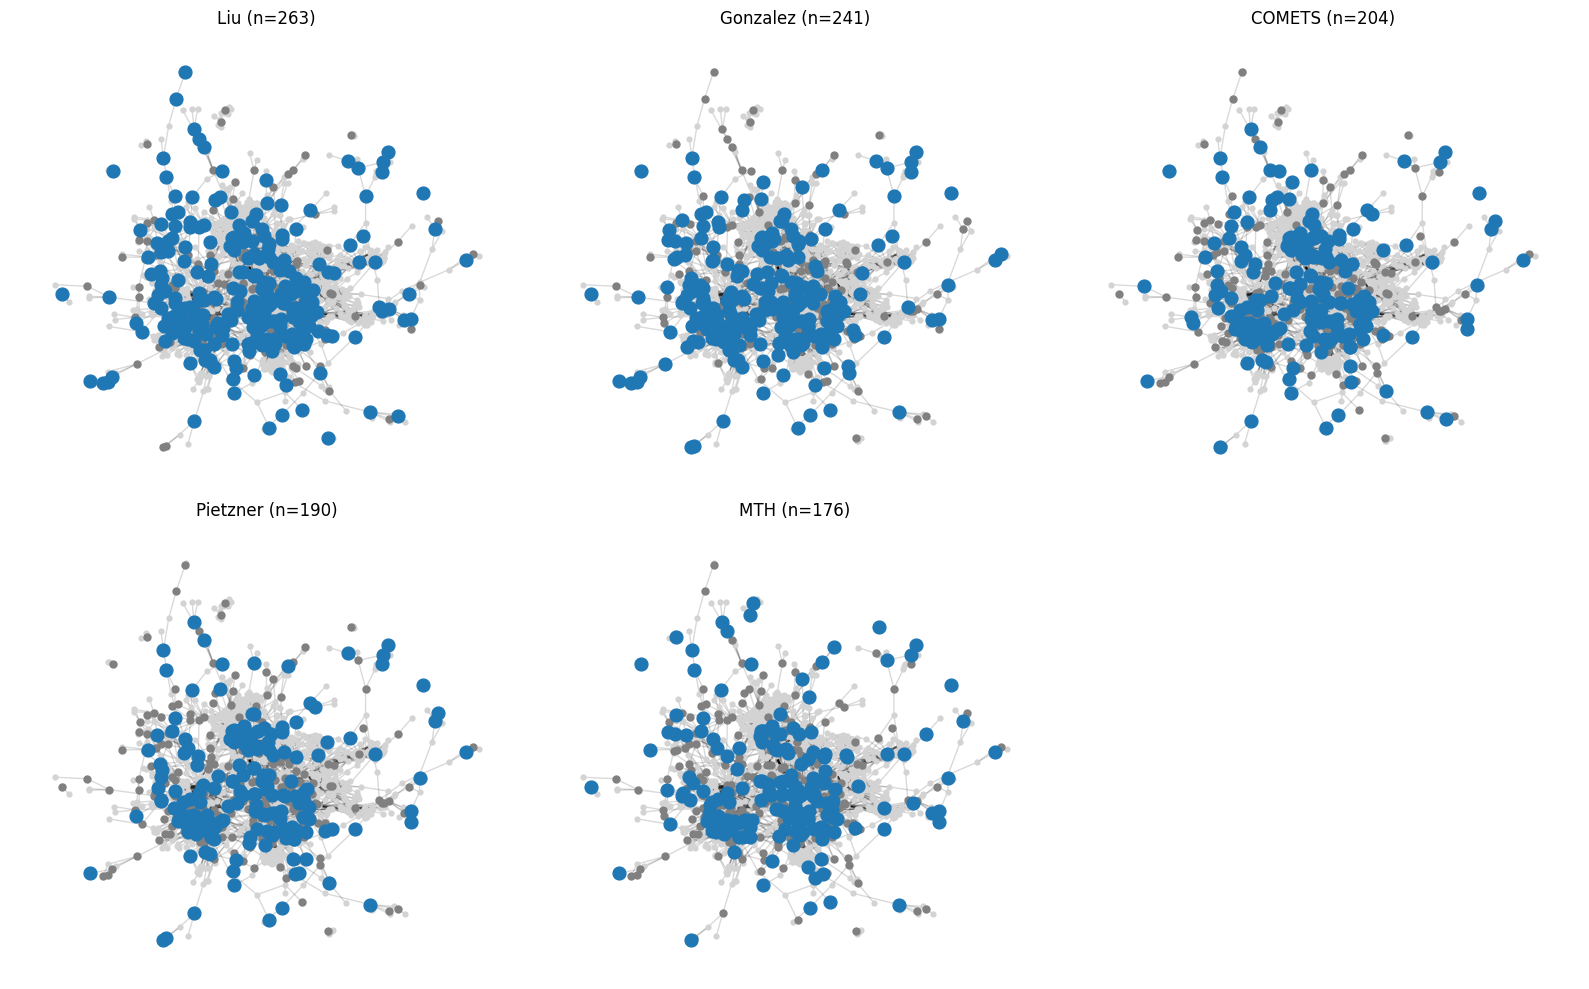

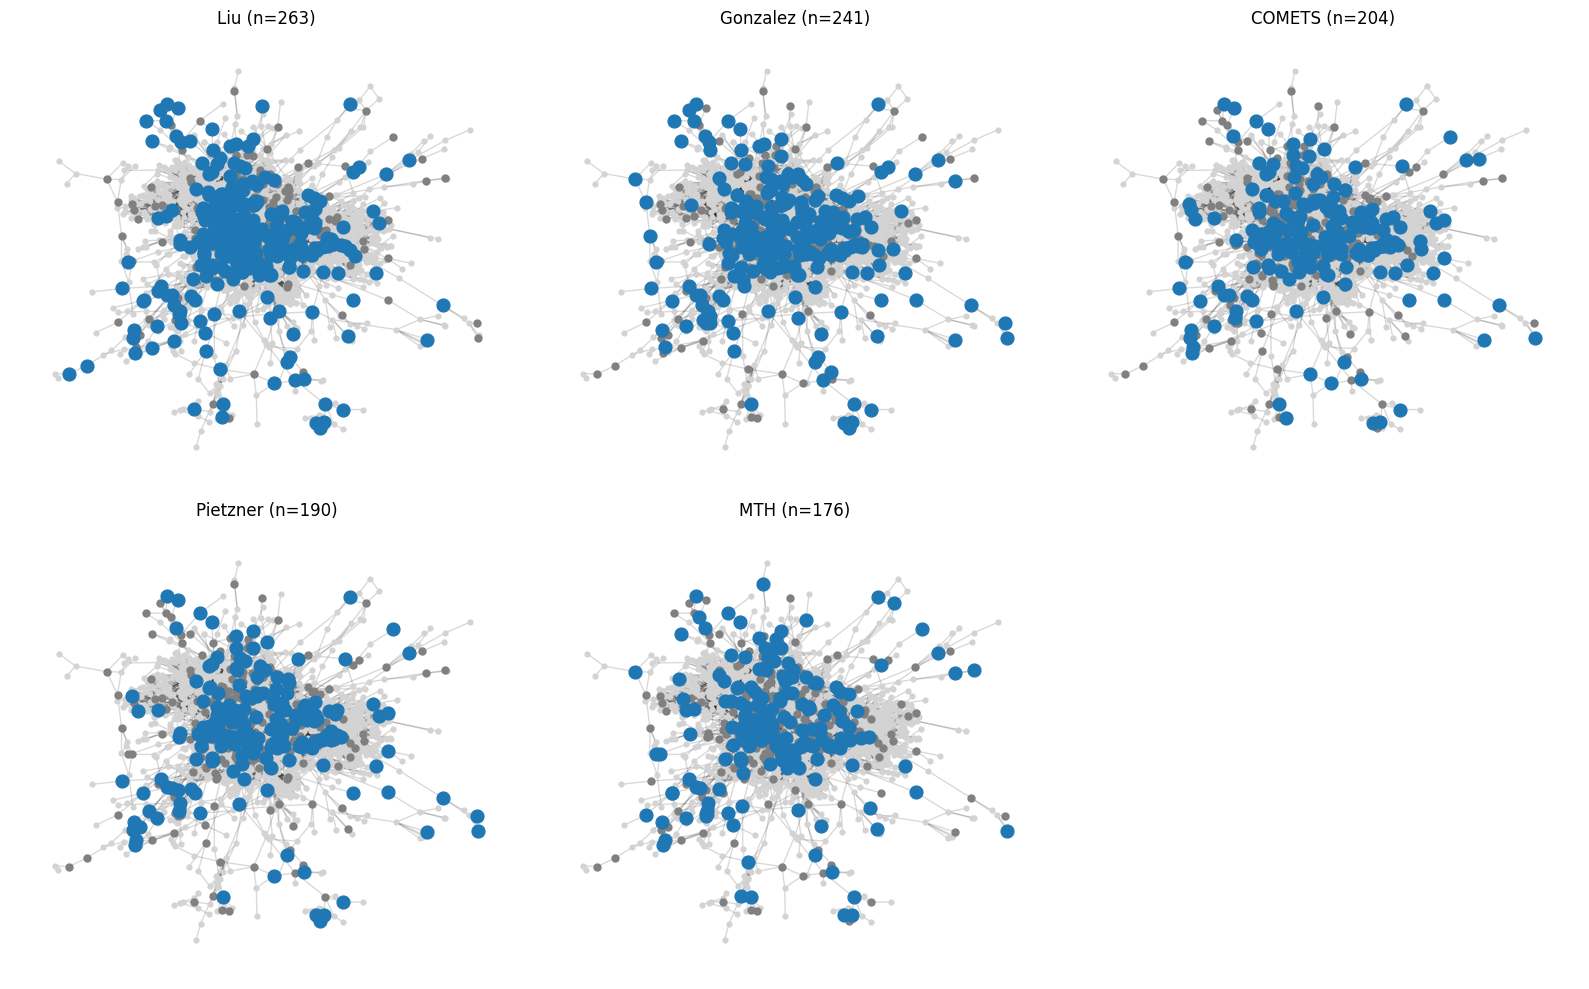

In [28]:
def plot_neighborhoods(radius):
    nodes = set(all_observed)
    for node in all_observed:
        nodes.update(nx.single_source_shortest_path_length(
            graph, node, cutoff=radius
        ))

    subgraph = graph.subgraph(nodes)
    pos = nx.spring_layout(subgraph, seed=42)
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    for ax, (name, highlighted) in zip(axes.flat, observed_by_list.items()):
        nx.draw_networkx_edges(subgraph, pos, ax=ax, alpha=0.15)
        nx.draw_networkx_nodes(
            subgraph, pos, nodelist=list(nodes - all_observed),
            node_color="lightgray", node_size=12, ax=ax
        )
        nx.draw_networkx_nodes(
            subgraph, pos, nodelist=list(all_observed - highlighted),
            node_color="gray", node_size=25, ax=ax
        )
        nx.draw_networkx_nodes(
            subgraph, pos, nodelist=list(highlighted),
            node_color="tab:blue", node_size=85, ax=ax
        )
        ax.set_title(f"{name} (n={len(highlighted)})")
        ax.axis("off")

    axes.flat[-1].axis("off")
    fig.tight_layout()
    plt.show()

plot_neighborhoods(radius=1)
plot_neighborhoods(radius=2)

In [29]:
observed_subgraphs = {}
component_rows = []

for name, indices in experiment_indices.items():
    nodes = [graph_nodes[i] for i in indices]
    subgraph = graph.subgraph(nodes).copy()
    observed_subgraphs[name] = subgraph

    sizes = sorted(
        (len(component) for component in nx.connected_components(subgraph)),
        reverse=True
    )

    component_rows.append({
        "list": name,
        "nodes": subgraph.number_of_nodes(),
        "edges": subgraph.number_of_edges(),
        "connected": len(sizes) == 1,
        "components": len(sizes),
        "largest_component": sizes[0],
        "largest_fraction": sizes[0] / len(nodes),
        "isolated_nodes": sizes.count(1),
    })

component_table = pd.DataFrame(component_rows).set_index("list")
display(component_table)

,nodes,edges,connected,components,largest_component,largest_fraction,isolated_nodes
list,,,,,,,
Liu,263,216,False,87,146,0.555133,74
Gonzalez,241,192,False,93,91,0.377593,77
COMETS,204,107,False,114,59,0.289216,96
Pietzner,190,88,False,119,23,0.121053,99
MTH,176,95,False,97,32,0.181818,75
Hajjar,420,418,False,115,263,0.626190,93


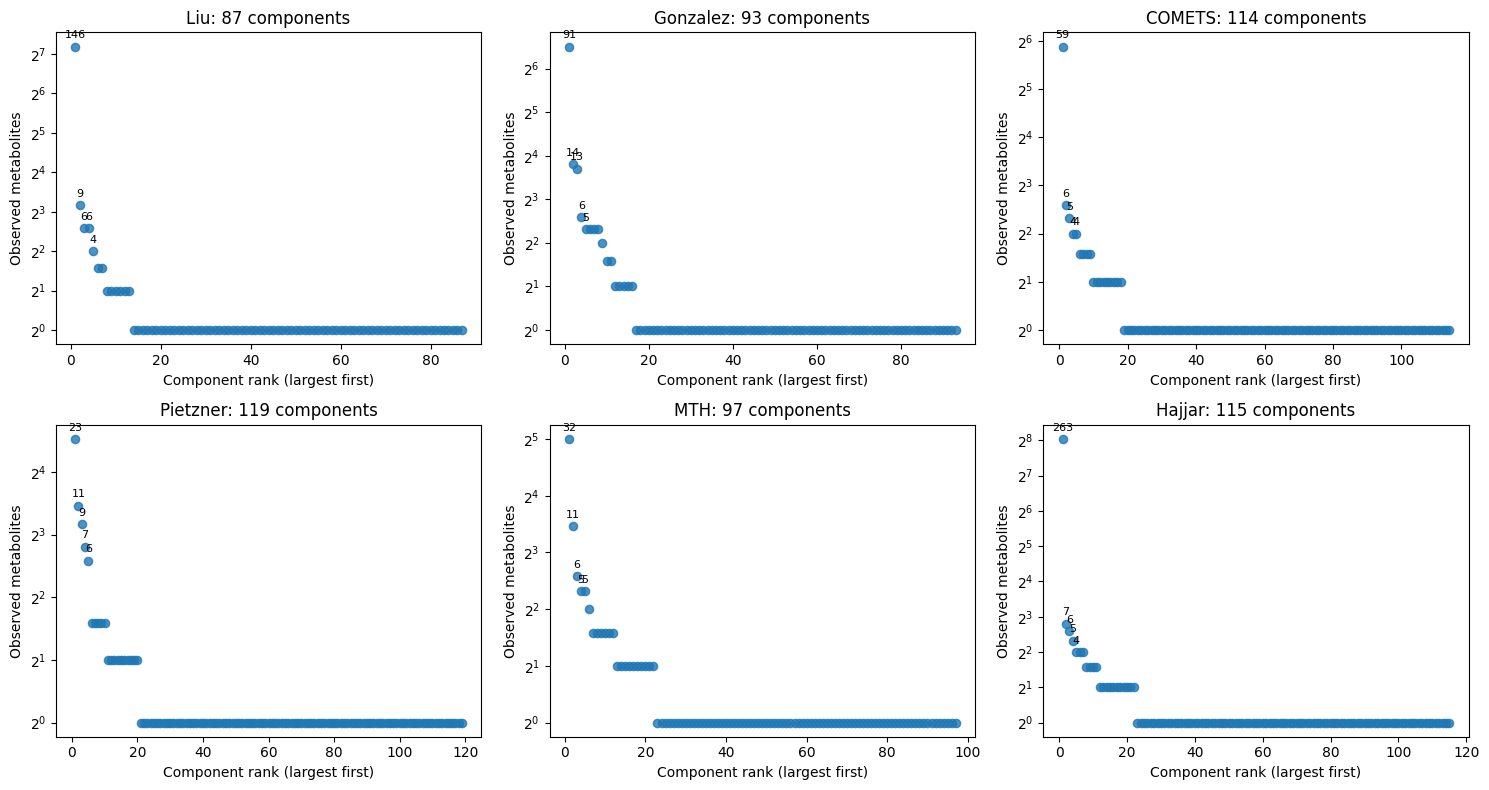

In [30]:
component_sizes = {
    name: sorted(
        (len(component) for component in nx.connected_components(subgraph)),
        reverse=True
    )
    for name, subgraph in observed_subgraphs.items()
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (name, sizes) in zip(axes.flat, component_sizes.items()):
    ranks = np.arange(1, len(sizes) + 1)
    ax.scatter(ranks, sizes, s=35, alpha=0.8)

    for rank, size in enumerate(sizes[:5], start=1):
        ax.annotate(str(size), (rank, size),
                    xytext=(0, 6), textcoords="offset points",
                    ha="center", fontsize=8)

    ax.set_title(f"{name}: {len(sizes)} components")
    ax.set_xlabel("Component rank (largest first)")
    ax.set_ylabel("Observed metabolites")
    ax.set_yscale("log", base=2)

fig.tight_layout()
plt.show()

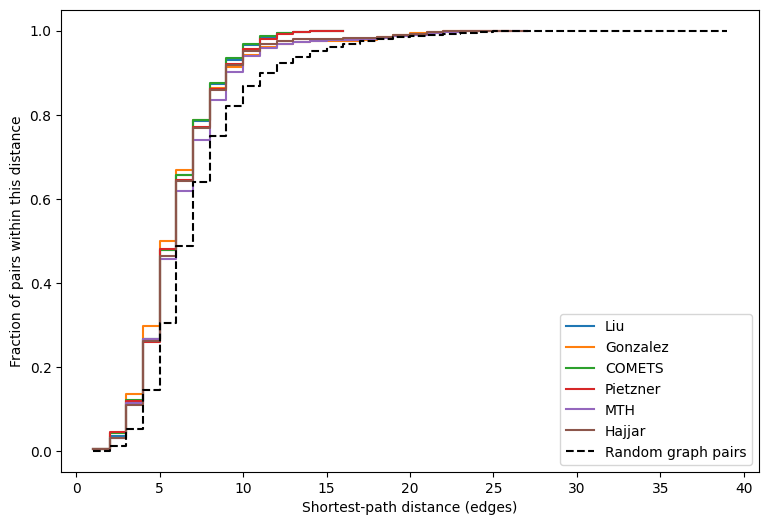

In [31]:
D = np.asarray(distance_matrix)
fig, ax = plt.subplots(figsize=(9, 6))

def add_distance_curve(distances, label, **style):
    values, counts = np.unique(distances, return_counts=True)
    fraction = np.cumsum(counts) / counts.sum()
    ax.step(values, fraction, where="post", label=label, **style)

for name, indices in experiment_indices.items():
    k = len(indices)
    distances = D[np.ix_(indices, indices)][np.triu_indices(k, 1)]
    add_distance_curve(distances, name)

# Descriptive reference: pairs of randomly chosen graph nodes
rng = np.random.default_rng(42)
a = rng.integers(len(graph_nodes), size=50_000)
b = rng.integers(len(graph_nodes), size=50_000)
different = a != b
add_distance_curve(D[a[different], b[different]],
                   "Random graph pairs", color="black", linestyle="--")

ax.set_xlabel("Shortest-path distance (edges)")
ax.set_ylabel("Fraction of pairs within this distance")
ax.legend()
plt.show()

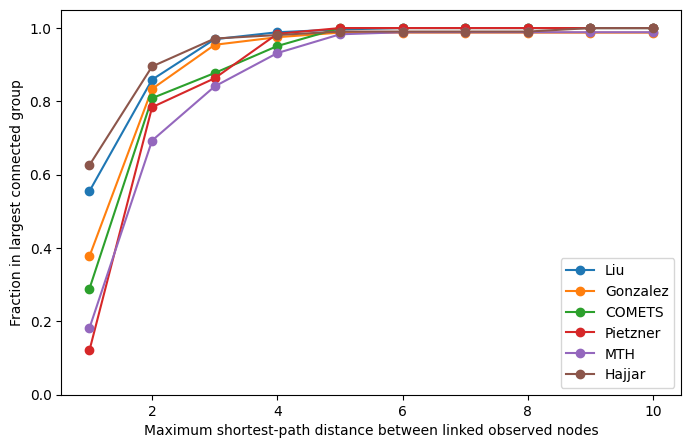

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
thresholds = range(1, 11)

for name, indices in experiment_indices.items():
    distances = D[np.ix_(indices, indices)]
    largest_fractions = []

    for threshold in thresholds:
        nearby = (distances > 0) & (distances <= threshold)
        proximity_graph = nx.from_numpy_array(nearby)
        largest = max(len(c) for c in nx.connected_components(proximity_graph))
        largest_fractions.append(largest / len(indices))

    ax.plot(thresholds, largest_fractions, marker="o", label=name)

ax.set_xlabel("Maximum shortest-path distance between linked observed nodes")
ax.set_ylabel("Fraction in largest connected group")
ax.set_ylim(0, 1.05)
ax.legend()
plt.show()

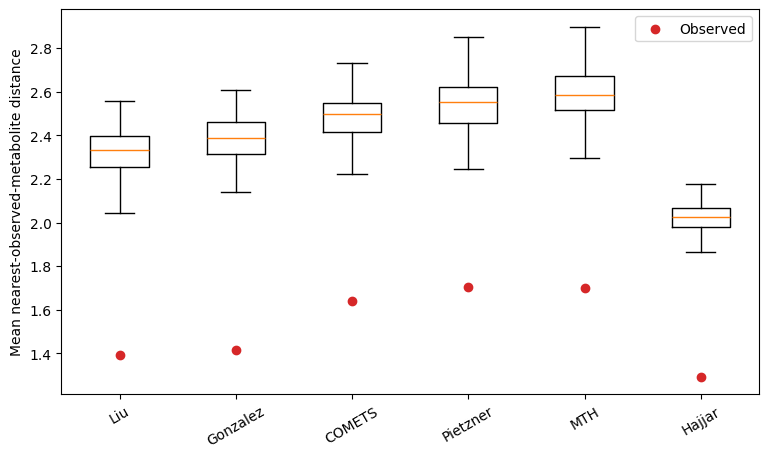

In [33]:
def mean_nearest_distance(indices):
    distances = D[np.ix_(indices, indices)].copy()
    np.fill_diagonal(distances, np.inf)
    return distances.min(axis=1).mean()

rng = np.random.default_rng(42)
observed_nn = {}
random_nn = {}

for name, indices in experiment_indices.items():
    k = len(indices)
    observed_nn[name] = mean_nearest_distance(indices)
    random_nn[name] = [
        mean_nearest_distance(rng.choice(len(graph_nodes), size=k, replace=False))
        for _ in range(200)
    ]

names = list(experiment_indices)
positions = range(1, len(names) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot([random_nn[name] for name in names],
           positions=positions, showfliers=False)
ax.scatter(positions, [observed_nn[name] for name in names],
           color="tab:red", zorder=3, label="Observed")

ax.set_xticks(list(positions), names, rotation=30)
ax.set_ylabel("Mean nearest-observed-metabolite distance")
ax.legend()
plt.show()

In [34]:
energy_comparison = pd.DataFrame([
    {
        "list": name,
        "k": len(indices),
        "observed_E": h_table.loc[name, "E"],
        "random_median_E": np.median(random_E[name]),
        "random_5th_percentile": np.percentile(random_E[name], 5),
        "random_95th_percentile": np.percentile(random_E[name], 95),
        "fraction_random_with_lower_E": (
            np.count_nonzero(random_E[name] <= h_table.loc[name, "E"]) + 1
        ) / (len(random_E[name]) + 1),
    }
    for name, indices in experiment_indices.items()
]).set_index("list")

display(energy_comparison)

,k,observed_E,random_median_E,random_5th_percentile,random_95th_percentile,fraction_random_with_lower_E
list,,,,,,
Liu,263,111.928045,26.556083,6.306200,42.356877,1.0000
Gonzalez,241,99.114967,22.323714,3.930663,36.703165,1.0000
COMETS,204,41.930549,16.001129,1.312796,27.417575,1.0000
Pietzner,190,31.775388,14.021605,0.640908,24.487595,0.9994
MTH,176,50.237097,11.958613,-0.343139,21.255126,1.0000
Hajjar,420,158.302098,66.664264,30.000478,97.035383,1.0000
